In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [ ]:
# Step 2: Load datasets
train_data = pd.read_csv("/content/fashion-mnist_train.csv")
test_data = pd.read_csv("/content/fashion-mnist_test.csv")


In [ ]:
X_train = train_data.iloc[:, 1:].values
y_train = train_data.iloc[:, 0].values

X_test = test_data.iloc[:, 1:].values
y_test = test_data.iloc[:, 0].values



In [ ]:
# Step 4: Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0


In [ ]:
# Step 5: Reshape for CNN
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


In [ ]:
# Step 6: Model
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Step 7: Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])



In [ ]:
# Step 8: Train
history = model.fit(X_train, y_train,
                    epochs=5,
                    validation_data=(X_test, y_test))


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 35ms/step - accuracy: 0.8227 - loss: 0.4862 - val_accuracy: 0.8768 - val_loss: nan
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.8845 - loss: 0.3224 - val_accuracy: 0.8945 - val_loss: nan
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9000 - loss: 0.2734 - val_accuracy: 0.9081 - val_loss: nan
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 65s 35ms/step - accuracy: 0.9109 - loss: 0.2402 - val_accuracy: 0.9091 - val_loss: nan
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9220 - loss: 0.2142 - val_accuracy: 0.9058 - val_loss: nan


In [ ]:
 #Step 9: Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


296/296 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9058 - loss: nan   
Test Accuracy: 0.9057940244674683


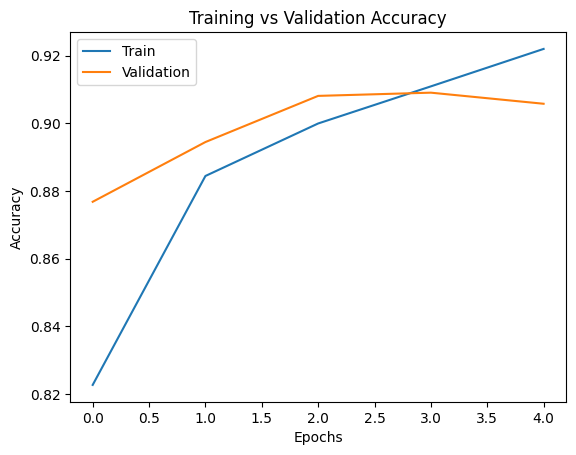

In [ ]:
# Step 10: Single Best Graph
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.show()


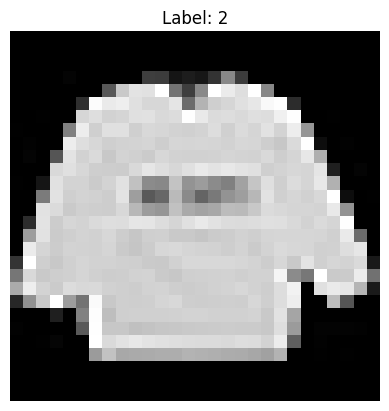

In [ ]:
plt.imshow(X_train[0].reshape(28,28), cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()